# Konfidenzintervall – einfach erklärt

> Quelle: [numiqo.de](https://numiqo.de/tutorial/konfidenzintervall)

Das **Konfidenzintervall (KI)** ist der Bereich, in dem ein Parameter der Grundgesamtheit
(z. B. der wahre Mittelwert) mit einer bestimmten Wahrscheinlichkeit liegt.

### Formeln

**Große Stichprobe (n ≥ 30, z-Verteilung):**
$$KI = \bar{x} \pm z_{\alpha/2} \cdot \frac{s}{\sqrt{n}}$$

**Kleine Stichprobe (n < 30, t-Verteilung):**
$$KI = \bar{x} \pm t_{\alpha/2,\, n-1} \cdot \frac{s}{\sqrt{n}}$$

| Begriff | Symbol | Bedeutung |
|---|---|---|
| Stichproben-Mittelwert | $\bar{x}$ | Schätzwert aus der Stichprobe |
| Standardfehler | $SE = s/\sqrt{n}$ | Genauigkeit der Schätzung |
| z-Wert (95 %-KI) | 1,96 | Kritischer Wert der Normalverteilung |
| z-Wert (99 %-KI) | 2,58 | Kritischer Wert für 99 % |
| t-Wert | $t_{\alpha/2,\,n-1}$ | Kritischer Wert der t-Verteilung |
| Konfidenzniveau | $1 - \alpha$ | Oft 95 % oder 99 % |

> **Korrekte Interpretation (numiqo):** Wenn man unendlich viele Stichproben zieht
> und jedes Mal ein 95%-KI berechnet, enthalten **95 % dieser Intervalle** den wahren
> Populationsparameter.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import norm as norm_dist, t as t_dist

np.random.seed(42)
print("Bibliotheken erfolgreich geladen.")

Bibliotheken erfolgreich geladen.


## 1. Intuition: Warum brauchen wir das KI?

Jede Stichprobe liefert einen **anderen Mittelwert** – keiner ist exakt gleich dem
wahren Populationsmittelwert. Das KI gibt einen **Bereich** an, in dem der wahre Wert
mit hoher Wahrscheinlichkeit liegt.

**Beispiel (numiqo):** Gehalt von Männern und Frauen – du willst wissen, in welchem
Bereich der wahre Mittelwertsunterschied in der Grundgesamtheit liegt.

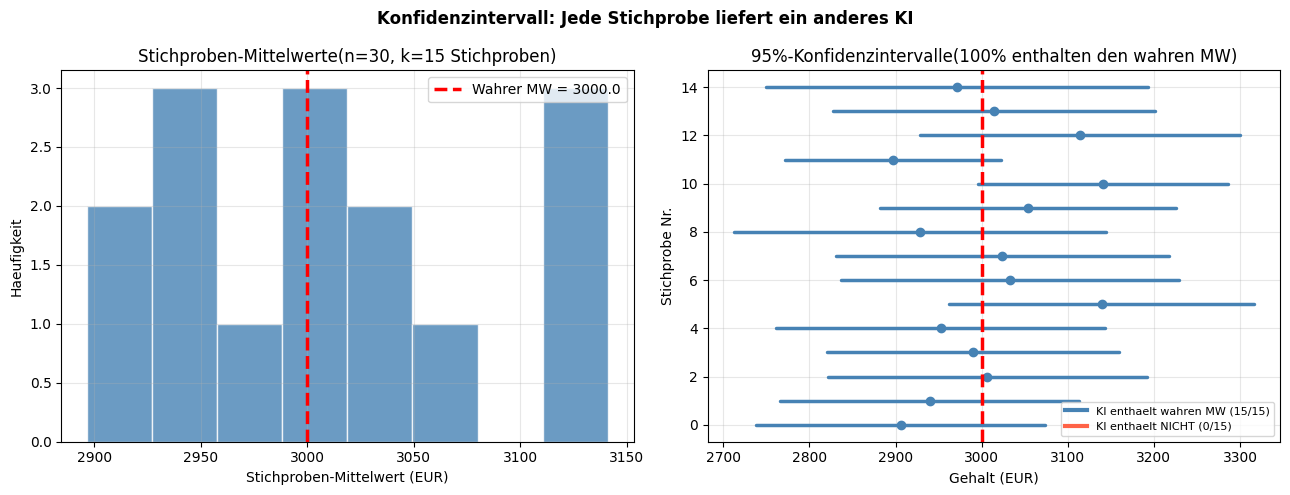

In [ ]:
# Intuition: Stichproben-Mittelwerte streuen um den wahren MW
np.random.seed(42)
mu_wahr = 3000.0   # wahrer Populationsmittelwert
sigma   = 500.0
n_stich = 30
k_stich = 15       # 15 Stichproben ziehen

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Konfidenzintervall: Jede Stichprobe liefert ein anderes KI",
             fontsize=12, fontweight="bold")

ki_grenzen = []
for i in range(k_stich):
    stichprobe = np.random.normal(mu_wahr, sigma, n_stich)
    mw_s  = stichprobe.mean()
    se_s  = stichprobe.std(ddof=1) / np.sqrt(n_stich)
    t_k   = t_dist.ppf(0.975, df=n_stich - 1)
    ki_u  = mw_s - t_k * se_s
    ki_o  = mw_s + t_k * se_s
    ki_grenzen.append((mw_s, ki_u, ki_o))

# Links: Histogramm der Stichproben-MW
mw_liste = [k[0] for k in ki_grenzen]
axes[0].hist(mw_liste, bins=8, color="steelblue", edgecolor="white", alpha=0.8)
axes[0].axvline(mu_wahr, color="red", linestyle="--", linewidth=2.5,
                label="Wahrer MW = " + str(mu_wahr))
axes[0].set_title("Stichproben-Mittelwerte(n=" + str(n_stich) + ", k=" + str(k_stich) + " Stichproben)")
axes[0].set_xlabel("Stichproben-Mittelwert (EUR)")
axes[0].set_ylabel("Häufigkeit")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Rechts: KIs visualisieren
farben = []
for i, (mw_s, ki_u, ki_o) in enumerate(ki_grenzen):
    enthaelt = ki_u <= mu_wahr <= ki_o
    farbe    = "steelblue" if enthaelt else "tomato"
    farben.append(farbe)
    axes[1].plot([ki_u, ki_o], [i, i], color=farbe, linewidth=2.5, solid_capstyle="round")
    axes[1].plot(mw_s, i, "o", color=farbe, markersize=6)

axes[1].axvline(mu_wahr, color="red", linestyle="--", linewidth=2.5,
                label="Wahrer MW = " + str(mu_wahr))
n_enthalten = sum(1 for f in farben if f == "steelblue")
blau  = plt.Line2D([0],[0], color="steelblue", lw=3,
                   label="KI enthaelt wahren MW (" + str(n_enthalten) + "/" + str(k_stich) + ")")
rot   = plt.Line2D([0],[0], color="tomato",    lw=3,
                   label="KI enthaelt NICHT (" + str(k_stich-n_enthalten) + "/" + str(k_stich) + ")")
axes[1].set_title("95%-Konfidenzintervalle(" + str(round(n_enthalten/k_stich*100)) + "% enthalten den wahren MW)")
axes[1].set_xlabel("Gehalt (EUR)")
axes[1].set_ylabel("Stichprobe Nr.")
axes[1].legend(handles=[blau, rot], fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Schritt-für-Schritt-Berechnung

### z-Werte für gängige Konfidenzniveaus

| Konfidenzniveau | α | α/2 | z-Wert |
|---|---|---|---|
| 90 % | 0,10 | 0,05 | 1,645 |
| **95 %** | **0,05** | **0,025** | **1,960** |
| **99 %** | **0,01** | **0,005** | **2,576** |

### Standardfehler (SE)

$$SE = \frac{s}{\sqrt{n}}$$

Je größer n, desto kleiner der SE → desto enger das KI → desto präziser die Schätzung.

In [14]:
# Schritt-für-Schritt: KI berechnen
np.random.seed(42)
gehalt = pd.Series(np.random.normal(3200, 600, 50))

n  = len(gehalt)
mw = gehalt.mean()
s  = gehalt.std(ddof=1)
se = s / np.sqrt(n)

print("Schritt-für-Schritt: 95%-Konfidenzintervall")
print(f"Daten: Gehalt (EUR), n={n}")
print(f"Schritt 1 - Mittelwert:        x_quer = {mw:.2f} EUR")
print(f"Schritt 2 - Standardabw.:      s      = {s:.2f} EUR")
print(f"Schritt 3 - Standardfehler:    SE     = {s:.2f} / sqrt({n}) = {se:.2f} EUR")
print()

# KI mit t-Verteilung (kleine Stichprobe korrekt)
t_k95 = t_dist.ppf(0.975, df=n-1)
t_k99 = t_dist.ppf(0.995, df=n-1)

ki95_u = mw - t_k95 * se
ki95_o = mw + t_k95 * se
ki99_u = mw - t_k99 * se
ki99_o = mw + t_k99 * se

print(f"Schritt 4 - Kritischer t-Wert (95%): t = {t_k95:.4f}  (df={n-1})")
print(f"Schritt 5 - 95%-KI:")
print(f"  Untergrenze: {mw:.2f} - {t_k95:.4f} * {se:.2f} = {ki95_u:.2f} EUR")
print(f"  Obergrenze:  {mw:.2f} + {t_k95:.4f} * {se:.2f} = {ki95_o:.2f} EUR")
print()
print(f"95%-KI:  [{ki95_u:.2f}, {ki95_o:.2f}] EUR")
print(f"99%-KI:  [{ki99_u:.2f}, {ki99_o:.2f}] EUR")
print()

# Verifikation mit scipy
ki_scipy = t_dist.interval(0.95, df=n-1, loc=mw, scale=se)
print(f"Kontrolle scipy: [{ki_scipy[0]:.2f}, {ki_scipy[1]:.2f}]")

Schritt-für-Schritt: 95%-Konfidenzintervall
Daten: Gehalt (EUR), n=50
Schritt 1 - Mittelwert:        x_quer = 3064.72 EUR
Schritt 2 - Standardabw.:      s      = 560.20 EUR
Schritt 3 - Standardfehler:    SE     = 560.20 / sqrt(50) = 79.22 EUR

Schritt 4 - Kritischer t-Wert (95%): t = 2.0096  (df=49)
Schritt 5 - 95%-KI:
  Untergrenze: 3064.72 - 2.0096 * 79.22 = 2905.51 EUR
  Obergrenze:  3064.72 + 2.0096 * 79.22 = 3223.92 EUR

95%-KI:  [2905.51, 3223.92] EUR
99%-KI:  [2852.40, 3277.03] EUR

Kontrolle scipy: [2905.51, 3223.92]


## 3. Konfidenzniveau: 95 % vs. 99 %

Ein **höheres Konfidenzniveau** bedeutet ein **breiteres Intervall**:
- 95%-KI: mit 95 % Sicherheit enthält das Intervall den wahren Parameter
- 99%-KI: mit 99 % Sicherheit → breiter, aber weniger präzise

> **Tradeoff:** Mehr Sicherheit kostet Präzision.

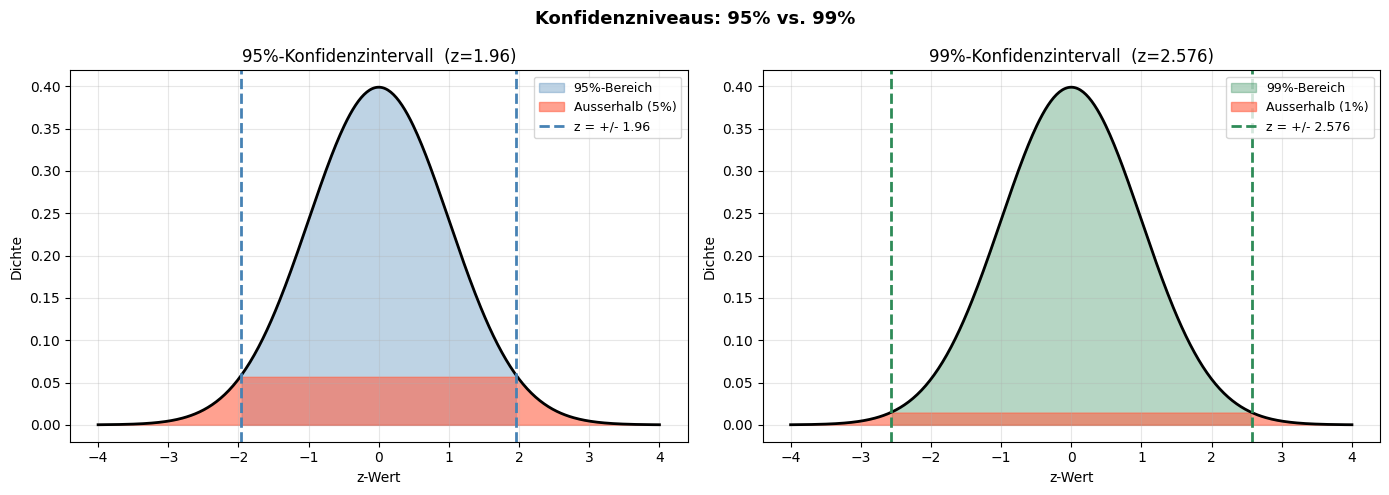

KI-Breiten im Vergleich
Gehalt-Stichprobe: n=50, MW=3064.7, SE=79.22
  90%-KI: [2934.4, 3195.0]  Breite: 260.6 EUR
  95%-KI: [2909.4, 3220.0]  Breite: 310.6 EUR
  99%-KI: [2860.6, 3268.8]  Breite: 408.2 EUR


In [9]:
# 95% vs. 99% KI auf der Normalverteilung
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Konfidenzniveaus: 95% vs. 99%", fontsize=13, fontweight="bold")

x = np.linspace(-4, 4, 400)
y = norm_dist.pdf(x, 0, 1)

for ax, konf, z_k, farbe in zip(
    axes,
    [95, 99],
    [1.96, 2.576],
    ["steelblue", "seagreen"]
):
    ax.plot(x, y, color="black", linewidth=2)
    mask = (x >= -z_k) & (x <= z_k)
    ax.fill_between(x[mask], y[mask], alpha=0.35, color=farbe,
                    label=str(konf) + "%-Bereich")
    ax.fill_between(x[~mask], y[~mask], alpha=0.6, color="tomato",
                    label="Ausserhalb (" + str(100-konf) + "%)")
    ax.axvline( z_k, color=farbe, linestyle="--", linewidth=2)
    ax.axvline(-z_k, color=farbe, linestyle="--", linewidth=2,
               label="z = +/- " + str(z_k))
    ax.set_title(str(konf) + "%-Konfidenzintervall  (z=" + str(z_k) + ")")
    ax.set_xlabel("z-Wert")
    ax.set_ylabel("Dichte")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Vergleich der KI-Breiten
print("KI-Breiten im Vergleich")
print(f"Gehalt-Stichprobe: n={n}, MW={mw:.1f}, SE={se:.2f}")
for konf, z_k in [(90, 1.645), (95, 1.96), (99, 2.576)]:
    breite = 2 * z_k * se
    ki_u_v = mw - z_k * se
    ki_o_v = mw + z_k * se
    print(f"  {konf}%-KI: [{ki_u_v:.1f}, {ki_o_v:.1f}]  Breite: {breite:.1f} EUR")

## 4. Einfluss der Stichprobengröße n

Je größer n, desto **kleiner der Standardfehler** → desto **enger das KI**:

$$SE = \frac{s}{\sqrt{n}} \quad \Rightarrow \quad \text{KI-Breite} \propto \frac{1}{\sqrt{n}}$$

**Verdoppelt man n, wird das KI um Faktor $\sqrt{2} \approx 1{,}41$ schmaler.**

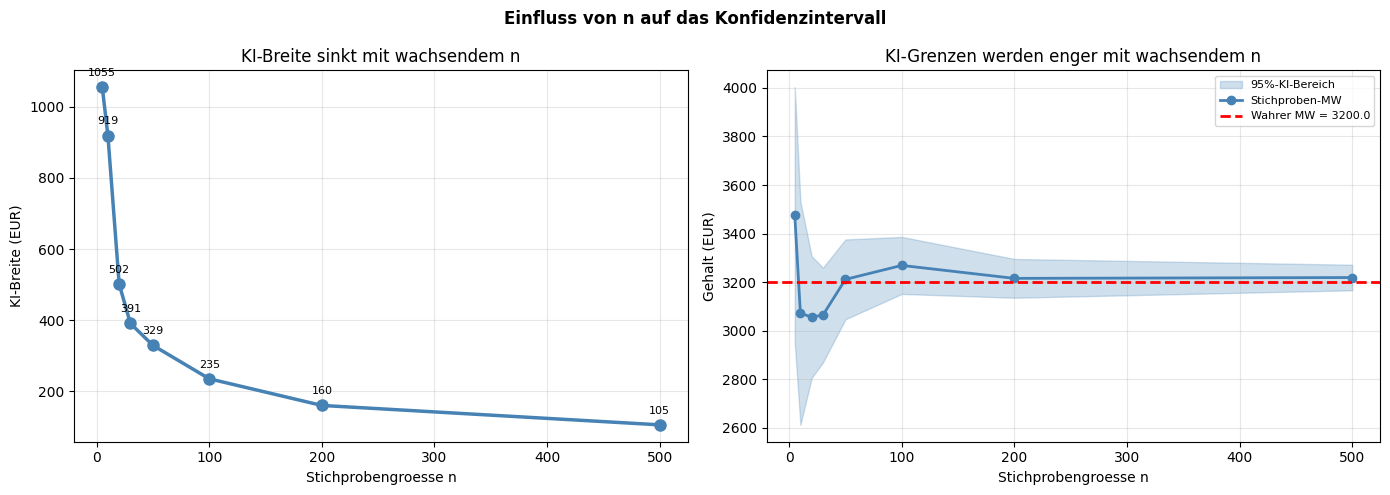

Fazit:
  n=5:   KI-Breite = 1055 EUR
  n=500: KI-Breite = 105 EUR
  Faktor: 10.0x schmaler


In [ ]:
# KI-Breite in Abhaengigkeit von n
np.random.seed(42)
mu_pop = 3200.0
sigma_pop = 600.0
n_werte = [5, 10, 20, 30, 50, 100, 200, 500]

ki_breiten = []
ki_unter   = []
ki_ober    = []

for n_s in n_werte:
    stich = np.random.normal(mu_pop, sigma_pop, n_s)
    mw_s  = stich.mean()
    se_s  = stich.std(ddof=1) / np.sqrt(n_s)
    t_k   = t_dist.ppf(0.975, df=n_s-1)
    ki_breiten.append(2 * t_k * se_s)
    ki_unter.append(mw_s - t_k * se_s)
    ki_ober.append(mw_s  + t_k * se_s)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Einfluss von n auf das Konfidenzintervall", fontsize=12, fontweight="bold")

# KI-Breite
axes[0].plot(n_werte, ki_breiten, "o-", color="steelblue", linewidth=2.5, markersize=8)
axes[0].set_title("KI-Breite sinkt mit wachsendem n")
axes[0].set_xlabel("Stichprobengröße n")
axes[0].set_ylabel("KI-Breite (EUR)")
axes[0].grid(alpha=0.3)
for n_s, b in zip(n_werte, ki_breiten):
    axes[0].annotate(str(round(b)), (n_s, b), textcoords="offset points",
                     xytext=(0, 8), ha="center", fontsize=8)

# KI-Grenzen
axes[1].fill_between(n_werte, ki_unter, ki_ober, alpha=0.25, color="steelblue",
                     label="95%-KI-Bereich")
axes[1].plot(n_werte, [(u+o)/2 for u, o in zip(ki_unter, ki_ober)],
             "o-", color="steelblue", linewidth=2, markersize=6, label="Stichproben-MW")
axes[1].axhline(mu_pop, color="red", linestyle="--", linewidth=2,
                label="Wahrer MW = " + str(mu_pop))
axes[1].set_title("KI-Grenzen werden enger mit wachsendem n")
axes[1].set_xlabel("Stichprobengroesse n")
axes[1].set_ylabel("Gehalt (EUR)")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Fazit:")
print(f"  n=5:   KI-Breite = {ki_breiten[0]:.0f} EUR")
print(f"  n=500: KI-Breite = {ki_breiten[-1]:.0f} EUR")
print(f"  Faktor: {ki_breiten[0]/ki_breiten[-1]:.1f}x schmaler")

## 5. Konfidenzintervall beim t-Test (numiqo-Beispiel)

**Beispiel (numiqo):** t-Test Gehalt Männer vs. Frauen – das KI des
Mittelwertsunterschieds zeigt, in welchem Bereich die wahre Differenz liegt.

**Interpretation des KI beim Gruppenvergleich:**
- KI enthält **nicht** 0 → Unterschied signifikant (entspricht p < 0,05)
- KI enthält **0** → Unterschied nicht signifikant (p ≥ 0,05)

t-Test: Gehalt Männer vs. Frauen
MW Männer:  3427.31 EUR  (n=100)
MW Frauen:   3215.17 EUR  (n=100)
Differenz:   212.14 EUR

t-Statistik: 2.3360
p-Wert:      0.0205

95%-KI der Differenz: [33.06, 391.22] EUR
KI enthaelt 0: False  -> Signifikant!


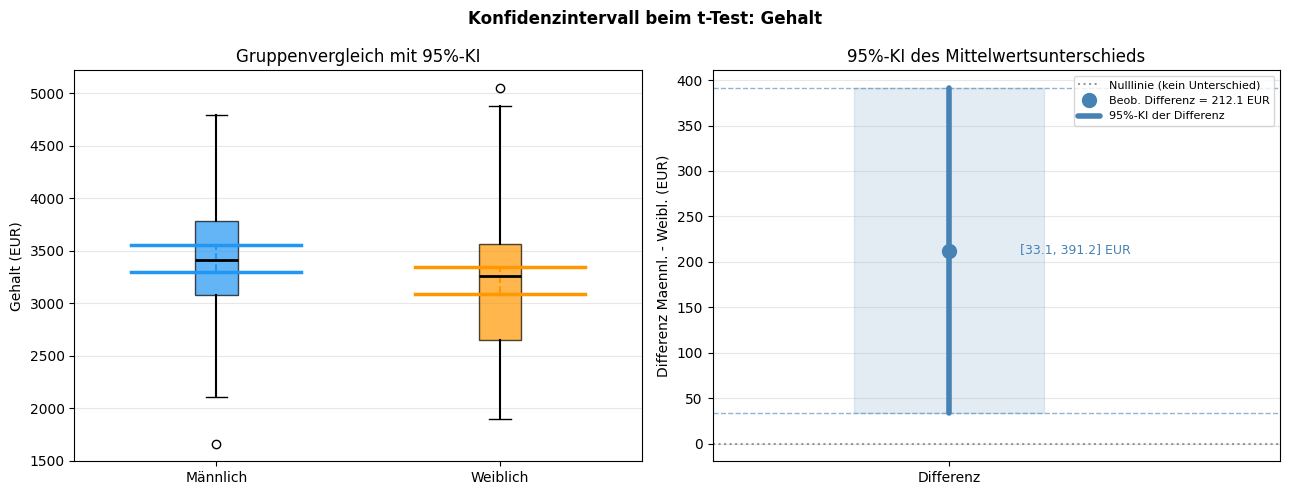

In [10]:
# KI beim t-Test: Gehalt Männer vs. Frauen
np.random.seed(42)
n_grp = 100
gehalt_m = pd.Series(np.random.normal(3500, 700, n_grp))
gehalt_w = pd.Series(np.random.normal(3200, 680, n_grp))

# t-Test
t_stat, p_wert = stats.ttest_ind(gehalt_m, gehalt_w)
differenz = gehalt_m.mean() - gehalt_w.mean()

# 95%-KI der Differenz
se_diff = np.sqrt(gehalt_m.var()/n_grp + gehalt_w.var()/n_grp)
df_diff = 2*n_grp - 2
t_k_d   = t_dist.ppf(0.975, df=df_diff)
ki_d_u  = differenz - t_k_d * se_diff
ki_d_o  = differenz + t_k_d * se_diff

print("t-Test: Gehalt Männer vs. Frauen")
print(f"MW Männer:  {gehalt_m.mean():.2f} EUR  (n={n_grp})")
print(f"MW Frauen:   {gehalt_w.mean():.2f} EUR  (n={n_grp})")
print(f"Differenz:   {differenz:.2f} EUR")
print()
print(f"t-Statistik: {t_stat:.4f}")
print(f"p-Wert:      {p_wert:.4f}")
print()
print(f"95%-KI der Differenz: [{ki_d_u:.2f}, {ki_d_o:.2f}] EUR")
enthaelt_null = ki_d_u <= 0 <= ki_d_o
print(f"KI enthaelt 0: {enthaelt_null}  -> {'Nicht signifikant' if enthaelt_null else 'Signifikant!'}")

# Individuelle KIs + Differenz-KI
ki_m = t_dist.interval(0.95, df=n_grp-1,
                        loc=gehalt_m.mean(),
                        scale=gehalt_m.std(ddof=1)/np.sqrt(n_grp))
ki_w = t_dist.interval(0.95, df=n_grp-1,
                        loc=gehalt_w.mean(),
                        scale=gehalt_w.std(ddof=1)/np.sqrt(n_grp))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Konfidenzintervall beim t-Test: Gehalt", fontsize=12, fontweight="bold")

# Gruppenboxplots mit KI-Linien
bp = axes[0].boxplot([gehalt_m, gehalt_w], patch_artist=True,
                     medianprops=dict(color="black", linewidth=2),
                     whiskerprops=dict(linewidth=1.5))
for patch, fc in zip(bp["boxes"], ["#2196F3", "#FF9800"]):
    patch.set_facecolor(fc)
    patch.set_alpha(0.7)

for idx, (ki, farbe, label) in enumerate([(ki_m, "#2196F3", "95%-KI Maennl."),
                                           (ki_w, "#FF9800", "95%-KI Weibl.")], 1):
    axes[0].plot([idx-0.3, idx+0.3], [ki[0], ki[0]], color=farbe, linewidth=2.5)
    axes[0].plot([idx-0.3, idx+0.3], [ki[1], ki[1]], color=farbe, linewidth=2.5)
    axes[0].plot([idx, idx], [ki[0], ki[1]], color=farbe, linewidth=1.5, linestyle="--")

axes[0].set_title("Gruppenvergleich mit 95%-KI")
axes[0].set_ylabel("Gehalt (EUR)")
axes[0].set_xticks([1, 2])
axes[0].set_xticklabels(["Männlich", "Weiblich"])
axes[0].grid(axis="y", alpha=0.3)

# Differenz-KI
axes[1].axhline(0, color="gray", linestyle=":", linewidth=1.5, alpha=0.8,
                label="Nulllinie (kein Unterschied)")
axes[1].plot([1], [differenz], "o", color="steelblue", markersize=10,
             label="Beob. Differenz = " + str(round(differenz, 1)) + " EUR")
axes[1].plot([1, 1], [ki_d_u, ki_d_o], color="steelblue", linewidth=4,
             solid_capstyle="round", label="95%-KI der Differenz")
axes[1].fill_between([0.8, 1.2], ki_d_u, ki_d_o, alpha=0.15, color="steelblue")
axes[1].axhline(ki_d_u, color="steelblue", linestyle="--", linewidth=1, alpha=0.6)
axes[1].axhline(ki_d_o, color="steelblue", linestyle="--", linewidth=1, alpha=0.6)
axes[1].annotate("[" + str(round(ki_d_u, 1)) + ", " + str(round(ki_d_o, 1)) + "] EUR",
                 xy=(1.15, (ki_d_u+ki_d_o)/2), fontsize=9, color="steelblue",
                 va="center")
axes[1].set_title("95%-KI des Mittelwertsunterschieds")
axes[1].set_ylabel("Differenz Maennl. - Weibl. (EUR)")
axes[1].set_xticks([1])
axes[1].set_xticklabels(["Differenz"])
axes[1].legend(fontsize=8)
axes[1].grid(axis="y", alpha=0.3)
axes[1].set_xlim(0.5, 1.7)

plt.tight_layout()
plt.show()

## 6. Häufige Missverständnisse

| ❌ Falsch | ✅ Richtig |
|---|---|
| „Der wahre MW liegt zu 95 % im KI" | „95 % aller so berechneten KIs enthalten den wahren MW" |
| KI = Bereich der Rohdaten | KI = Bereich des **Parameters** (z. B. MW), nicht der Einzelwerte |
| Breiteres KI = mehr Unsicherheit über die Daten | Breiteres KI = weniger Präzision der **Schätzung** |
| KI und p-Wert sagen immer dasselbe | Meistens konsistent: KI enthält 0 ↔ p ≥ 0,05 |

In [13]:
# Wiederverwendbare KI-Funktion
def konfidenzintervall(daten, konfidenzniveau=0.95, name="Variable"):
    d   = np.asarray(daten)
    n   = len(d)
    mw  = d.mean()
    s   = d.std(ddof=1)
    se  = s / np.sqrt(n)
    df  = n - 1
    alpha_v = 1 - konfidenzniveau
    t_k = t_dist.ppf(1 - alpha_v/2, df=df)
    ki_u = mw - t_k * se
    ki_o = mw + t_k * se

    print(f"{int(konfidenzniveau*100)}%-Konfidenzintervall: {name}")
    print(f"n={n}  MW={mw:.3f}  s={s:.3f}  SE={se:.3f}")
    print(f"t_krit (df={df}) = {t_k:.4f}")
    print(f"KI = [{ki_u:.3f}, {ki_o:.3f}]")
    print(f"KI-Breite = {ki_o - ki_u:.3f}")
    return ki_u, ki_o

# Tests
np.random.seed(42)
koerpergroesse = np.random.normal(170, 10, 40)
konfidenzintervall(koerpergroesse, 0.95, "Körpergröße (cm)")
print()
konfidenzintervall(koerpergroesse, 0.99, "Körpergröße (cm)")

95%-Konfidenzintervall: Körpergröße (cm)
n=40  MW=167.814  s=9.528  SE=1.507
t_krit (df=39) = 2.0227
KI = [164.766, 170.861]
KI-Breite = 6.094

99%-Konfidenzintervall: Körpergröße (cm)
n=40  MW=167.814  s=9.528  SE=1.507
t_krit (df=39) = 2.7079
KI = [163.734, 171.893]
KI-Breite = 8.159


(np.float64(163.73409737023093), np.float64(171.8931658614103))

## 7. Zusammenfassung

```
Konfidenzintervall – Übersicht
│
├── DEFINITION
│   Bereich, in dem der wahre Populationsparameter
│   mit einer bestimmten Wahrscheinlichkeit liegt
│   Korrekt: 95% aller so berechneten KIs enthalten den wahren Wert
│
├── FORMEL
│   Grosse Stichprobe (n >= 30): KI = x_quer +/- z * (s / sqrt(n))
│   Kleine Stichprobe (n < 30):  KI = x_quer +/- t * (s / sqrt(n))
│   mit SE = s / sqrt(n) (Standardfehler)
│
├── KONFIDENZNIVEAUS
│   90%: z = 1.645
│   95%: z = 1.960  <- am haeufigsten
│   99%: z = 2.576
│   Höhere Sicherheit = breiteres KI
│
├── EINFLUSS VON n
│   Größeres n -> kleinerer SE -> engeres KI -> praezisere Schaetzung
│   KI-Breite ~ 1 / sqrt(n)
│
├── KI BEIM HYPOTHESENTEST
│   KI enthaelt NICHT 0 -> Unterschied signifikant (p < 0.05)
│   KI enthaelt 0       -> Nicht signifikant (p >= 0.05)
│
└── HAEUFIGE FEHLER
    "Wahrer MW liegt zu 95% im KI" -> FALSCH
    KI = Bereich der Rohdaten      -> FALSCH (KI gilt für den Parameter)
```

---
Quelle: [numiqo.de/tutorial/konfidenzintervall](https://numiqo.de/tutorial/konfidenzintervall)